 # Load the Data

In [1]:
# Load relevant data
import numpy as np
import mne
import sys
import os.path
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mne.datasets.fieldtrip_cmc import data_path
from mne_connectivity import spectral_connectivity_epochs

number_of_channels = 16
sample_rate = 250.4
sample_datatype = 'int16'
display_decimation = 1

# Load files
filename="/Users/sekemiadenuga/Documents/Dissertation/Data/TAINI_1033_S7063_Baseline1-2020_01_27-0000.dat"

def load_dat(filename):
    '''Load a .dat file by interpreting it as int16 and then de-interlacing the 16 channels'''
   
    print("Loading_" + filename)

    # Load the raw (1-D) data
    dat_raw = np.fromfile(filename, dtype=sample_datatype)

    # Reshape the (2-D) per channel data
    step = number_of_channels * display_decimation
    dat_chans = [dat_raw[c::step] for c in range(number_of_channels)]

    # Build the time array
    t = np.arange(len(dat_chans[0]), dtype=float) / display_decimation

    data=np.array(dat_chans)
    print(len(data))
    del(dat_chans)
   
    n_channels=16

    channel_names=['1', '2', '3', '4', '5',
                           '6', '7', '8', '9', '10',
                           '11', '12', '13', '14', '15', '16']
##    channel_names=['PVN', 'PVN', 'EMG', 'MC_conra', 'MS',
#                           'MC_ipsi', 'MC_ipsi', 'MS', 'MEC', 'MEC',
#                           'MHPC_contra', 'blank', 'Mhpc_contra', 'MC_contra', 'Mhps_ipsi', 'Mhpc_ipsi']
    channel_types=['eeg','emg','eeg','eeg','eeg','eeg','eeg','eeg','eeg','eeg','eeg','eeg','eeg','eeg','eeg','eeg']
         
       
    'This creates the info that goes with the channels, which is names, sampling rate, and channel types.'
    info = mne.create_info(channel_names, sample_rate, channel_types)
   
   
    'This makes the object that contains all the data and info about the channels.'
    'Computations like plotting, averaging, power spectrums can be performed on this object'
   
    custom_raw = mne.io.RawArray( data, info)
    
   
    return custom_raw

custom_raw = load_dat(filename)  

Loading_/Users/sekemiadenuga/Documents/Dissertation/Data/TAINI_1033_S7063_Baseline1-2020_01_27-0000.dat
16
Creating RawArray with float64 data, n_channels=16, n_times=62187522
    Range : 0 ... 62187521 =      0.000 ... 248352.720 secs
Ready.


In [2]:
# Select relevant channels
channels_to_keep = ['3', '14', '1', '16','7', '9'] # edit according to channels required

custom_raw.pick(channels_to_keep)

custom_raw.load_data()

print("Remaining channels:", custom_raw.ch_names)

Remaining channels: ['3', '14', '1', '16', '7', '9']


In [2]:
# File paths
sample_file = "/Users/sekemiadenuga/Documents/Dissertation/Data/Sample_start_end_SYNGAP.xlsx"
seizure_file = "/Users/sekemiadenuga/Documents/Dissertation/Data/S7063_BL1_Seizures_pre_120s.csv"

# Sampling rate
sampling_rate = 250.4  # Hz

# Load sample start
sample_df = pd.read_excel(sample_file)
first_row = sample_df.iloc[0]
start_sample = first_row['Start']
start_seconds = start_sample / sampling_rate

print(f"Start of recording in seconds: {start_seconds:.2f}")

# Load seizure data
seizure_df = pd.read_csv(seizure_file, sep='\t')
first_seizure = seizure_df.iloc[0]

# Extract seizure onset
seizure_onset = first_seizure["sec_start"]
seizure_time = start_seconds + seizure_onset

print(f"1st seizure onset: {seizure_onset:.2f} seconds")

Start of recording in seconds: 61200.00
1st seizure onset: 1624.30 seconds


## Create 1 plot with the 4 time windows and selected channel pairs

In [5]:
# Define the time windows
windows = {
    "55–60 s pre-ictal": (-60, -55),
    "25–30 s pre-ictal": (-30, -25),
    "0–5 s pre-ictal": (-5, 0),
    "0–5 s ictal": (0, 5),
}

# Channel pairs and associated colours
channels = [
    ('9', 'mediumorchid'),
    ('7', 'purple'),
    ('16', 'hotpink'),
    ('1', 'deeppink'),
    ('14', 'royalblue'),
    ('3', 'navy'),
]

# Ragional map
region_map = {
    '9':  "L. V1 (Monocular)",
    '7':  "R. V1 (Monocular)",
    '16': "L. S1 (Trunk)",
    '1':  "R. S1 (Trunk)",
    '14': "L. M2",
    '3':  "R. M2",
}

# Create legend and order the pairs
legend_order = [
    '3', '14',   
    '1', '16',  
    '7', '9',   
]

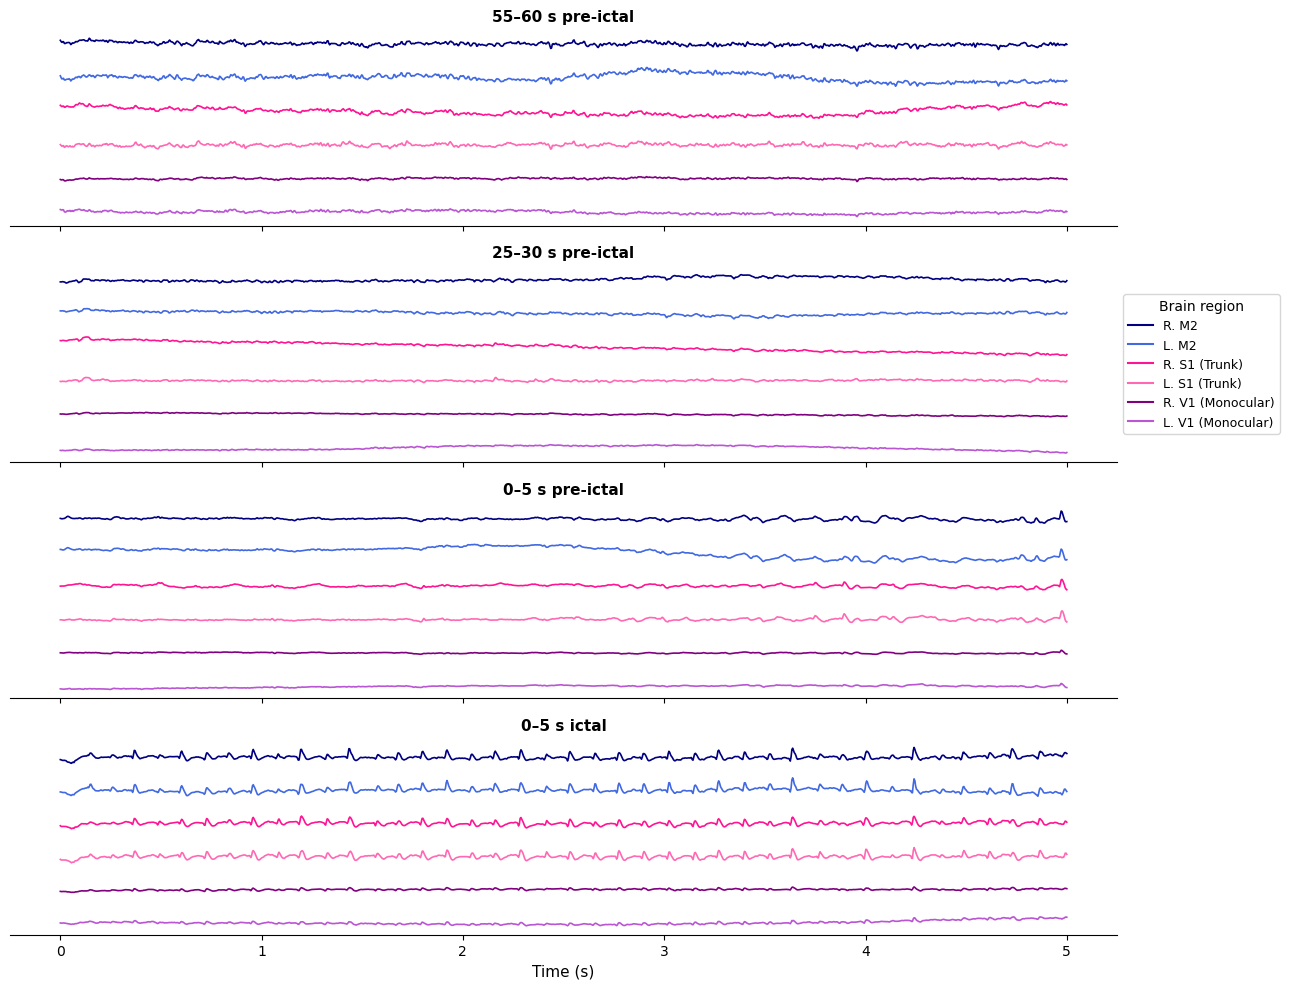

In [6]:
# Map channel and colour
colour_map = {ch: colour for ch, colour in channels}

legend_elements = [
    Line2D([0], [0],
           color=colour_map[ch],
           label=region_map[ch])
    for ch in legend_order
]

# Setup the plot
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=False)

# Loop through the windows
for ax, (title, (t1, t2)) in zip(axes, windows.items()):

    tmin = max(0, seizure_time + t1)
    tmax = seizure_time + t2

    raw_window = custom_raw.copy().crop(tmin=tmin, tmax=tmax)
    data, times = raw_window.get_data(return_times=True)
    ch_names = raw_window.ch_names

    # Preprocess
    data -= data.mean(axis=1, keepdims=True)

    # Select channels
    signals = []
    colours = []
    labels = []

    for ch, colour in channels:
        idx = ch_names.index(ch)
        signals.append(data[idx])
        colours.append(colour)
        labels.append(region_map[ch])

    signals = np.array(signals)

    spacing = np.max(np.ptp(signals, axis=1)) * 1.8

    # Signals to be plotted
    for i, signal in enumerate(signals):
        ax.plot(
            times,
            signal + i * spacing,
            color=colours[i],
            linewidth=1.2
        )
        
    # Y-axis labels
    yticks = [i * spacing for i in range(len(labels))]
    ax.set_yticks([])

    # Styling
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)

    # Label only bottom x-axis
    if ax != axes[-1]:
        ax.tick_params(axis='x', labelbottom=False)

# Style 1 legend for all the plots
axes[1].legend(
    handles=legend_elements,
    title="Brain region",
    fontsize=9,
    title_fontsize=10,
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

# Labels + title
axes[-1].set_xlabel("Time (s)", fontsize=11)

plt.tight_layout()
plt.show()